In [33]:
## Random Forest

import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [35]:
df = sns.load_dataset("tips")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [28]:
for col in df.select_dtypes('category').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [31]:
X = df.drop('sex', axis=1)
y = df['sex']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = RandomForestClassifier(n_estimators=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

<Axes: >

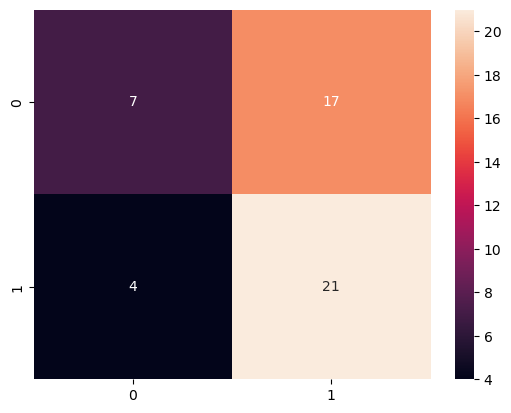

In [32]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [ ]:
## RFR

df = sns.load_dataset('tips')

for col in df.select_dtypes(include=['category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
X = df.drop('tip', axis=1)
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = RandomForestRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")

MAE: 0.7213163265306123
R2: 0.584860171294667
